In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import shutil

shutil.copy(
    '/kaggle/input/datasets/sushanthkolakaleti/helper-utils/helper_utils.py',
    '/kaggle/working/helper_utils.py'
)

import helper_utils

torch.manual_seed(45)

In [2]:
# Distances in miles for recent bike deliveries
distances = torch.tensor([[1.0], [2.0], [3.0], [4.0]], dtype=torch.float32)

# Corresponding delivery times in minutes
times = torch.tensor([[6.96], [12.11], [16.77], [22.21]], dtype=torch.float32)

In [3]:
# building the model

model = nn.Sequential(nn.Linear(1,1))

In [4]:
# loss fn and optimizer
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)

In [5]:
# training the model

for epoch in range(500) :
    optimizer.zero_grad()
    output = model(distances)
    loss = loss_fn(output,times)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0 :
        print(f"Epoch {epoch+1}--> Loss : {loss.item()}")

Epoch 50--> Loss : 0.11382327973842621
Epoch 100--> Loss : 0.09091746807098389
Epoch 150--> Loss : 0.07394888252019882
Epoch 200--> Loss : 0.061376381665468216
Epoch 250--> Loss : 0.05206052213907242
Epoch 300--> Loss : 0.04515829682350159
Epoch 350--> Loss : 0.0400441475212574
Epoch 400--> Loss : 0.03625515475869179
Epoch 450--> Loss : 0.033447299152612686
Epoch 500--> Loss : 0.03136715665459633


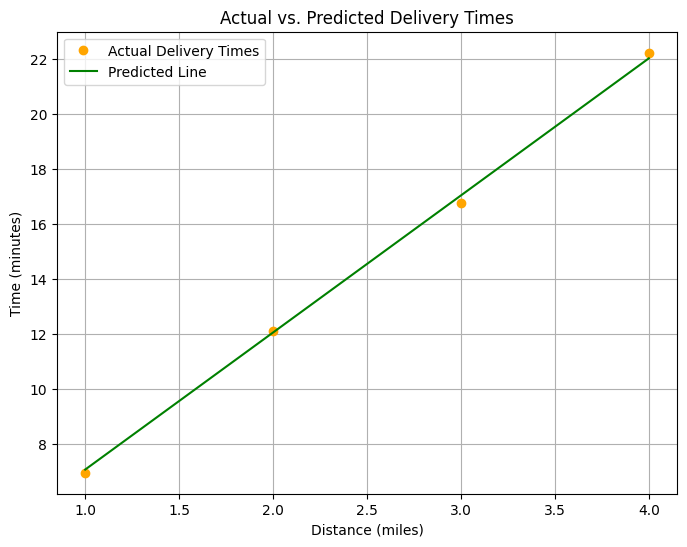

In [7]:
helper_utils.plot_results(model,distances,times)

In [12]:
# testing
new_distance = 7.0

with torch.no_grad() :
    new_distance = torch.tensor([[new_distance]], dtype = torch.float32)
    pred_time = model(new_distance)
    print(f"The time taken to cover {new_distance.numpy().item()} miles is {pred_time.item():.1f} minutes")
    

The time taken to cover 7.0 miles is 36.9 minutes


In [13]:
# inspecting the model's learning
layer = model[0]
weight = layer.weight.data.item()
bias = layer.bias.data.item()
print(f"Weight : {weight}\nBias : {bias}")

Weight : 4.976995468139648
Bias : 2.098180055618286
